# **Kuis Praktikum Scraping, Eksplorasi Data Teks & Analisis Sentimen**

**Program Studi**: Statistika/Data Science <br>
**Mata Kuliah**: Eksplorasi Data

In [29]:
# Import necessary libraries
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

## - Import Data

In [30]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.linkedin.android&hl=en"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.linkedin.android


## - Reviews Of Comments

In [27]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='id',   # Language: English
    country='id',  # Country: US
    count=10000,   # Fetch 200 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,544fa502-c04c-4e50-96e1-ac1472a6c72f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,belum masuk ke ktp sh group lagi,2,0,None,2026-05-10 02:40:29,Hai - Untuk layanan pelanggan dalam bahasa Ind...,2026-05-10 03:36:20,None
1,fd89c036-0fa0-4b25-8fdb-28a2320f161d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,makin gak jelas. akun tiba2 dibatasi karena lo...,1,0,4.1.1171,2026-05-09 22:15:24,Hai - Untuk layanan pelanggan dalam bahasa Ind...,2026-05-09 22:45:12,4.1.1171
2,dc591a42-5e28-4e59-851e-a4c963d5bfba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mau login tp gak ada metode verivikasi lain ap...,1,0,4.1.1201,2026-05-09 15:20:30,Hai - Untuk layanan pelanggan dalam bahasa Ind...,2026-05-09 18:49:09,4.1.1201
3,57cfb14a-e508-4ab5-86dc-afd02081f3f7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,oke,4,0,4.1.1201,2026-05-09 14:29:47,None,NaT,4.1.1201
4,e1d1fc22-2eeb-48dc-a389-0e11a37e7f60,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,3,0,None,2026-05-09 12:49:28,None,NaT,None
...,...,...,...,...,...,...,...,...,...,...,...
9995,4efb83f7-750c-4ab4-80e7-84153cfb6cda,Amang Udin,https://play-lh.googleusercontent.com/a/ACg8oc...,Mntap,5,1,4.1.718.1,2022-08-17 18:34:04,None,NaT,4.1.718.1
9996,92730dab-7ff5-49e8-b3fc-d1279c25fb38,Mul Yadi,https://play-lh.googleusercontent.com/a/ACg8oc...,Sangat membantu,5,1,4.1.718.1,2022-08-17 14:28:30,None,NaT,4.1.718.1
9997,ae32299e-f8e8-4244-b6f2-835d044edef8,budiman aja,https://play-lh.googleusercontent.com/a-/ALV-U...,Ok,5,1,4.1.713,2022-08-17 14:23:19,None,NaT,4.1.713
9998,0d0078c8-a398-4a05-ae0b-370accaeeb2c,luthfi abbas,https://play-lh.googleusercontent.com/a/ACg8oc...,I'm happy with join linked,5,1,4.1.601,2022-08-17 13:22:29,None,NaT,4.1.601


In [28]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,544fa502-c04c-4e50-96e1-ac1472a6c72f,belum masuk ke ktp sh group lagi,2
1,fd89c036-0fa0-4b25-8fdb-28a2320f161d,makin gak jelas. akun tiba2 dibatasi karena lo...,1
2,dc591a42-5e28-4e59-851e-a4c963d5bfba,mau login tp gak ada metode verivikasi lain ap...,1
3,57cfb14a-e508-4ab5-86dc-afd02081f3f7,oke,4
4,e1d1fc22-2eeb-48dc-a389-0e11a37e7f60,bagus,3
...,...,...,...
9995,4efb83f7-750c-4ab4-80e7-84153cfb6cda,Mntap,5
9996,92730dab-7ff5-49e8-b3fc-d1279c25fb38,Sangat membantu,5
9997,ae32299e-f8e8-4244-b6f2-835d044edef8,Ok,5
9998,0d0078c8-a398-4a05-ae0b-370accaeeb2c,I'm happy with join linked,5


In [31]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Inggris
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,content,cleaned_text
0,belum masuk ke ktp sh group lagi,belum masuk ke ktp sh group lagi
1,makin gak jelas. akun tiba2 dibatasi karena lo...,makin gak jelas akun tiba dibatasi karena logi...
2,mau login tp gak ada metode verivikasi lain ap...,mau login tp gak ada metode verivikasi lain ap...
3,oke,oke
4,bagus,bagus
5,kurang jelas,kurang jelas
6,oke,oke
7,saya suka sekali,saya suka sekali
8,Aplikasi ini bagus banget 👍🏻✨✨✨ (⁠人⁠ ⁠•͈⁠ᴗ⁠•͈⁠),aplikasi ini bagus banget 人 ᴗ
9,akun saya tiba2 ilang dan tiap mau masuk minta...,akun saya tiba ilang dan tiap mau masuk minta ...


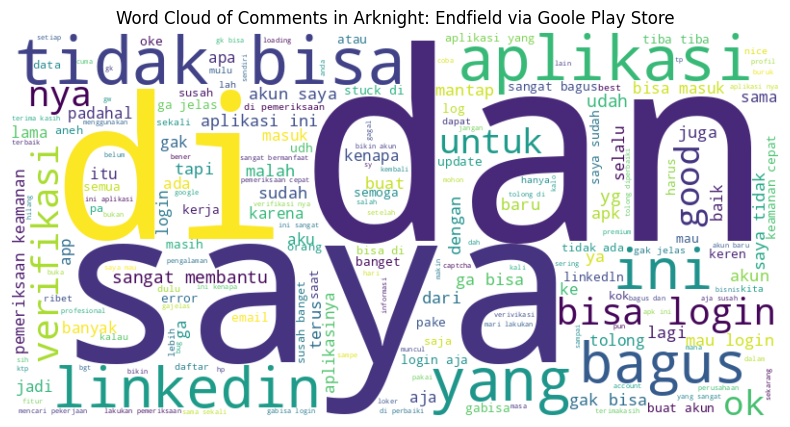

In [32]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in Arknight: Endfield via Goole Play Store")
plt.show()

           Word  Frequency
36         saya       2012
84         bisa       1642
148          di       1625
14        login       1391
31     aplikasi       1324
83        tidak       1204
44          dan       1167
39          ini       1043
10         akun       1039
68       sangat       1032
20   verifikasi        886
96         yang        823
34        bagus        784
25          mau        680
52           ga        679
89          nya        673
119        good        651
364       untuk        631
362    linkedin        591
8           gak        576


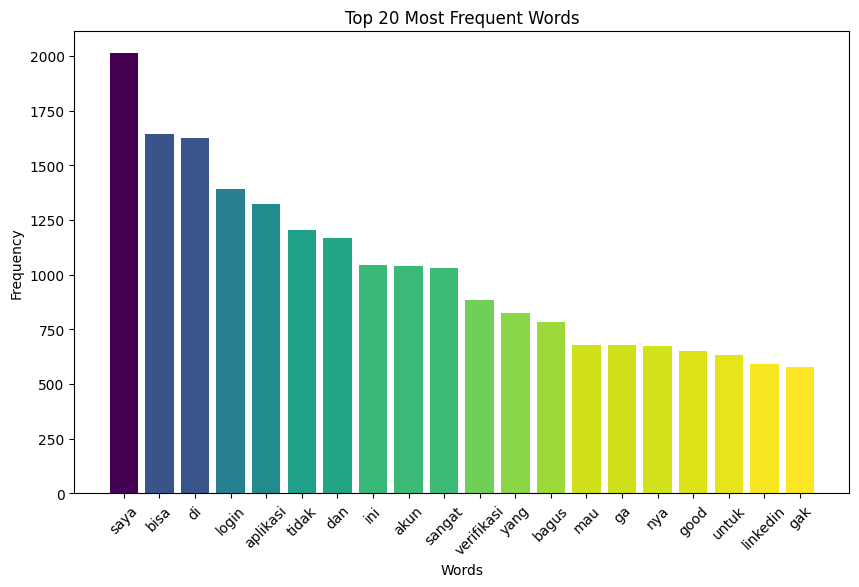

In [33]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

## - Training Model

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(10000, 9215)


In [35]:

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (10000, 9477)
Dimensi target y: (10000,)


In [36]:

from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 8000
Jumlah data testing: 2000


## - Akurasi Model

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression()

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 90.85%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.85      0.89       903
    Positive       0.89      0.95      0.92      1097

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [38]:

def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "semangat ya untuk pengembangannya, semoga kedepannya bisa lebih baik lagi"
test_sentence_2 = "aplikasi yang sangat buruk"

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'semangat ya untuk pengembangannya, semoga kedepannya bisa lebih baik lagi'
Prediksi: Positive

Review: 'aplikasi yang sangat buruk'
Prediksi: Negative


In [39]:

# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,belum masuk ke ktp sh group lagi,2,Negative
1,makin gak jelas. akun tiba2 dibatasi karena lo...,1,Negative
2,mau login tp gak ada metode verivikasi lain ap...,1,Negative
3,oke,4,Positive
4,bagus,3,Positive


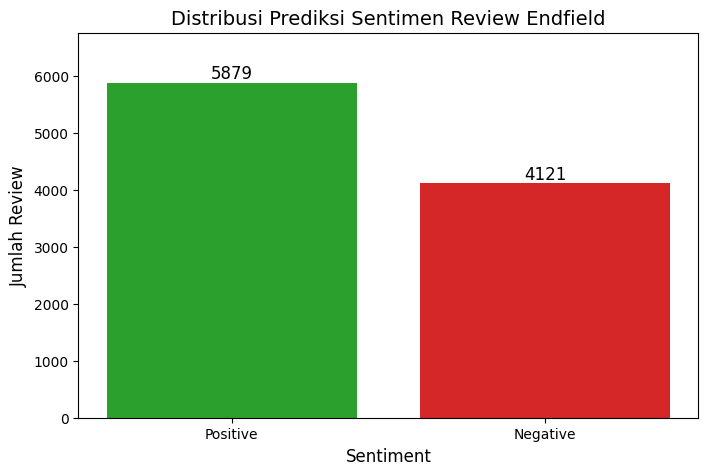

In [40]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2ca02c', '#d62728']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Endfield', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()

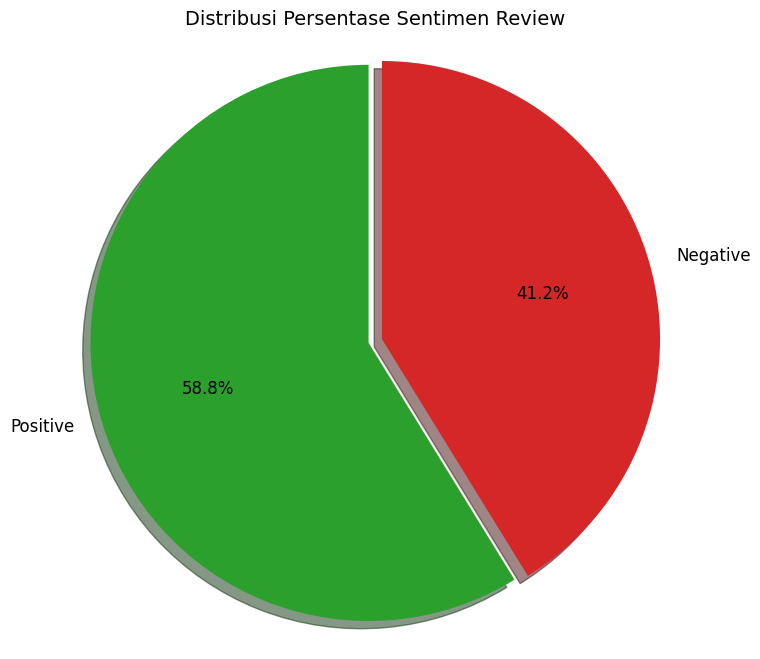

In [41]:
import matplotlib.pyplot as plt

# Calculate percentages
total_reviews = sentiment_counts.sum()
sentiment_percentages = (sentiment_counts / total_reviews) * 100

# Membuat Pie Chart
plt.figure(figsize=(8, 8))
colors = ['#2ca02c', '#d62728'] # Hijau & Merah
explode = [0.05, 0]  # Slice the 'Positive' sentiment slightly

plt.pie(sentiment_percentages, labels=sentiment_percentages.index,
        autopct='%1.1f%%', colors=colors, explode=explode, shadow=True,
        startangle=90, textprops={'fontsize': 12})

plt.title('Distribusi Persentase Sentimen Review', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()